# 02 — Data Cleaning & Preprocessing

**Project:** Financial Fraud Detection System  
**Step:** 6 — Data Cleaning & Preprocessing  
**Dataset:** `data/raw/synthetic_fraud_dataset1 (1).csv`

---

## Objective

This notebook performs data cleaning and preprocessing on the raw financial fraud dataset identified in Step 5 (Dataset Inspection).  
All transformations are applied to a **working copy** — the raw CSV file is **never** modified.

**Scope of this notebook:**
- Validate the raw dataset (shape, types, missing values, duplicates)
- Handle missing values and duplicate rows (if any actually exist)
- Convert the `Date` column from string to datetime
- Validate numeric and categorical columns
- Investigate Transaction_Amount outliers (without arbitrary removal)
- Separate features (`X`) and target (`y`)
- Design a reproducible preprocessing pipeline (encoding + scaling) using scikit-learn
- Extract useful date-based features
- Perform final validation

**Not in scope:** model training, evaluation, SMOTE, train-test splitting, hyperparameter tuning, deployment.

---
## 1. Import Required Libraries

In [1]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


---
## 2. Load Raw Dataset

In [2]:
# Robust relative path from notebooks/ to the raw data file
DATA_PATH = os.path.join("..", "data", "raw", "synthetic_fraud_dataset1 (1).csv")

raw_df = pd.read_csv(DATA_PATH)

print(f"Raw dataset loaded from: {DATA_PATH}")
print(f"Shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")

Raw dataset loaded from: ..\data\raw\synthetic_fraud_dataset1 (1).csv
Shape: 50,000 rows × 14 columns


---
## 3. Create a Working Copy

All preprocessing is performed on `df` (the working copy).  
The `raw_df` and the original CSV file remain untouched.

In [3]:
df = raw_df.copy()

print(f"Working copy created — shape: {df.shape}")

Working copy created — shape: (50000, 14)


---
## 4. Initial Validation

Programmatically verify the dataset's shape, columns, types, missing values, duplicates, target existence, and basic invalid values.

In [4]:
print("=" * 60)
print("INITIAL VALIDATION")
print("=" * 60)

# Shape
n_rows, n_cols = df.shape
print(f"\n1. Shape: {n_rows:,} rows × {n_cols} columns")

# Column names
print(f"\n2. Columns ({n_cols}):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

# Data types
print("\n3. Data Types:")
for col in df.columns:
    print(f"   {col:35s} {str(df[col].dtype)}")

# Missing values
total_missing = df.isnull().sum().sum()
print(f"\n4. Total missing values: {total_missing}")
if total_missing > 0:
    print("   Per-column missing:")
    missing_per_col = df.isnull().sum()
    for col in missing_per_col[missing_per_col > 0].index:
        print(f"     {col}: {missing_per_col[col]}")
else:
    print("   ✓ No missing values detected.")

# Duplicates
n_duplicates = df.duplicated().sum()
print(f"\n5. Duplicate rows: {n_duplicates}")
if n_duplicates == 0:
    print("   ✓ No duplicate rows detected.")

# Target column existence
target_col = "Fraud_Label"
if target_col in df.columns:
    print(f"\n6. Target column '{target_col}' exists — unique values: {sorted(df[target_col].unique())}")
else:
    print(f"\n6. ✗ Target column '{target_col}' NOT found!")

# Basic invalid value checks (NaN/inf in numeric columns)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
inf_count = np.isinf(df[numeric_cols]).sum().sum()
print(f"\n7. Infinite values in numeric columns: {inf_count}")
if inf_count == 0:
    print("   ✓ No infinite values detected.")

print("\n" + "=" * 60)
print("INITIAL VALIDATION COMPLETE")
print("=" * 60)

INITIAL VALIDATION

1. Shape: 50,000 rows × 14 columns

2. Columns (14):
    1. Transaction_ID
    2. User_ID
    3. Transaction_Amount
    4. Transaction_Type
    5. Date
    6. Account_Balance
    7. Device_Type
    8. Location
    9. Merchant_Category
   10. Previous_Fraudulent_Activity
   11. Daily_Transaction_Count
   12. Card_Type
   13. Card_Age
   14. Fraud_Label

3. Data Types:
   Transaction_ID                      object
   User_ID                             object
   Transaction_Amount                  float64
   Transaction_Type                    object
   Date                                object
   Account_Balance                     float64
   Device_Type                         object
   Location                            object
   Merchant_Category                   object
   Previous_Fraudulent_Activity        int64
   Daily_Transaction_Count             int64
   Card_Type                           object
   Card_Age                            int64
   Fraud_Labe

---
## 5. Handle Missing Values

Re-check for missing values. If any are found, handle them with a sensible method based on column type. If none exist, report and move on.

In [5]:
missing_before = df.isnull().sum()
total_missing_before = missing_before.sum()

print("Missing values per column:")
print(missing_before.to_string())
print(f"\nTotal missing values: {total_missing_before}")

if total_missing_before == 0:
    print("\n✓ The dataset contains zero missing values.")
    print("  No imputation or filling is required.")
else:
    # If missing values are present, handle them by type
    print("\nHandling missing values...")
    for col in missing_before[missing_before > 0].index:
        if df[col].dtype in ["float64", "int64"]:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"  {col}: filled {missing_before[col]} NaN(s) with median ({median_val})")
        else:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"  {col}: filled {missing_before[col]} NaN(s) with mode ('{mode_val}')")
    
    remaining = df.isnull().sum().sum()
    print(f"\n  Missing values after handling: {remaining}")

Missing values per column:
Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Date                            0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Card_Type                       0
Card_Age                        0
Fraud_Label                     0

Total missing values: 0

✓ The dataset contains zero missing values.
  No imputation or filling is required.


---
## 6. Handle Duplicate Rows

Check for and report duplicate rows. Remove only if they actually exist.

In [6]:
n_dup_before = df.duplicated().sum()
print(f"Duplicate rows found: {n_dup_before}")

if n_dup_before > 0:
    shape_before = df.shape[0]
    df = df.drop_duplicates().reset_index(drop=True)
    shape_after = df.shape[0]
    print(f"  Rows before removal: {shape_before:,}")
    print(f"  Rows after removal:  {shape_after:,}")
    print(f"  Removed: {shape_before - shape_after:,} duplicate rows.")
else:
    print("\n✓ No duplicate rows found. No rows were removed.")
    print(f"  Dataset shape remains: {df.shape}")

Duplicate rows found: 0

✓ No duplicate rows found. No rows were removed.
  Dataset shape remains: (50000, 14)


---
## 7. Data Type Correction — Date Column

The `Date` column is stored as a string (e.g., `"14 August 2023"`).  
Convert it to pandas `datetime64` using the format `"%d %B %Y"` with safe error handling.

In [7]:
print(f"Date column dtype BEFORE conversion: {df['Date'].dtype}")
print(f"Sample values: {df['Date'].head(3).tolist()}")

# Convert with explicit format; errors='coerce' turns unparseable dates to NaT
df["Date"] = pd.to_datetime(df["Date"], format="%d %B %Y", errors="coerce")

print(f"\nDate column dtype AFTER conversion: {df['Date'].dtype}")

# Check for conversion failures (NaT values)
nat_count = df["Date"].isna().sum()
print(f"Unparseable / NaT dates after conversion: {nat_count}")

if nat_count == 0:
    print("✓ All dates parsed successfully.")
else:
    print(f"✗ WARNING: {nat_count} date(s) could not be parsed and are now NaT.")

print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Sample converted values: {df['Date'].head(3).tolist()}")

Date column dtype BEFORE conversion: object
Sample values: ['14 August 2023', '7 June 2023', '20 June 2023']

Date column dtype AFTER conversion: datetime64[ns]
Unparseable / NaT dates after conversion: 0
✓ All dates parsed successfully.

Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00
Sample converted values: [Timestamp('2023-08-14 00:00:00'), Timestamp('2023-06-07 00:00:00'), Timestamp('2023-06-20 00:00:00')]


---
## 8. Validate Numeric Columns

Inspect the numeric columns for NaN, infinite values, impossible negative values, invalid binary values, and suspicious ranges.

In [8]:
numeric_columns = [
    "Transaction_Amount",
    "Account_Balance",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Card_Age",
    "Fraud_Label",
]

print("=" * 60)
print("NUMERIC COLUMN VALIDATION")
print("=" * 60)

for col in numeric_columns:
    print(f"\n--- {col} ---")
    series = df[col]
    
    # NaN check
    nan_count = series.isna().sum()
    print(f"  NaN values:      {nan_count}")
    
    # Infinite check
    inf_count = np.isinf(series).sum()
    print(f"  Infinite values: {inf_count}")
    
    # Negative check (all these columns should be non-negative)
    neg_count = (series < 0).sum()
    print(f"  Negative values: {neg_count}")
    if neg_count > 0:
        print(f"    ⚠ WARNING: {neg_count} unexpected negative values found.")
    
    # Range
    print(f"  Range:           [{series.min()}, {series.max()}]")
    print(f"  Mean / Std:      {series.mean():.4f} / {series.std():.4f}")
    
    # Binary validation for binary columns
    if col in ["Previous_Fraudulent_Activity", "Fraud_Label"]:
        unique_vals = sorted(series.unique())
        is_valid_binary = set(unique_vals).issubset({0, 1})
        print(f"  Unique values:   {unique_vals}")
        print(f"  Valid binary:    {'✓ Yes' if is_valid_binary else '✗ No — unexpected values detected!'}")

print("\n" + "=" * 60)
print("✓ Numeric validation complete. No corrections needed.")
print("=" * 60)

NUMERIC COLUMN VALIDATION

--- Transaction_Amount ---
  NaN values:      0
  Infinite values: 0
  Negative values: 0
  Range:           [0.0, 1174.14]
  Mean / Std:      99.4110 / 98.6873

--- Account_Balance ---
  NaN values:      0
  Infinite values: 0
  Negative values: 0
  Range:           [500.48, 99998.31]
  Mean / Std:      50294.0660 / 28760.4586

--- Previous_Fraudulent_Activity ---
  NaN values:      0
  Infinite values: 0
  Negative values: 0
  Range:           [0, 1]
  Mean / Std:      0.0984 / 0.2979
  Unique values:   [np.int64(0), np.int64(1)]
  Valid binary:    ✓ Yes

--- Daily_Transaction_Count ---
  NaN values:      0
  Infinite values: 0
  Negative values: 0
  Range:           [1, 14]
  Mean / Std:      7.4852 / 4.0396

--- Card_Age ---
  NaN values:      0
  Infinite values: 0
  Negative values: 0
  Range:           [1, 239]
  Mean / Std:      119.9999 / 68.9858

--- Fraud_Label ---
  NaN values:      0
  Infinite values: 0
  Negative values: 0
  Range:           [0

---
## 9. Validate Categorical Columns

Inspect categorical columns for missing values, blank strings, whitespace issues, and formatting inconsistencies.

In [9]:
categorical_columns = [
    "Transaction_Type",
    "Device_Type",
    "Location",
    "Merchant_Category",
    "Card_Type",
]

print("=" * 60)
print("CATEGORICAL COLUMN VALIDATION")
print("=" * 60)

for col in categorical_columns:
    print(f"\n--- {col} ---")
    series = df[col]
    
    # Missing values
    n_missing = series.isna().sum()
    print(f"  Missing values:    {n_missing}")
    
    # Blank strings
    n_blank = (series.astype(str).str.strip() == "").sum()
    print(f"  Blank strings:     {n_blank}")
    
    # Whitespace issues (leading/trailing)
    stripped = series.astype(str).str.strip()
    n_whitespace = (series.astype(str) != stripped).sum()
    print(f"  Whitespace issues: {n_whitespace}")
    
    if n_whitespace > 0:
        df[col] = stripped
        print(f"    → Stripped leading/trailing whitespace from {n_whitespace} value(s).")
    
    # Unique values
    unique_vals = sorted(df[col].unique())
    print(f"  Unique values ({len(unique_vals)}): {unique_vals}")

print("\n" + "=" * 60)
print("✓ Categorical validation complete.")
print("=" * 60)

CATEGORICAL COLUMN VALIDATION

--- Transaction_Type ---
  Missing values:    0
  Blank strings:     0
  Whitespace issues: 0
  Unique values (4): ['ATM Withdrawal', 'Bank Transfer', 'Online', 'POS']

--- Device_Type ---
  Missing values:    0
  Blank strings:     0
  Whitespace issues: 0
  Unique values (3): ['Laptop', 'Mobile', 'Tablet']

--- Location ---
  Missing values:    0
  Blank strings:     0
  Whitespace issues: 0
  Unique values (5): ['London', 'Mumbai', 'New York', 'Sydney', 'Tokyo']

--- Merchant_Category ---
  Missing values:    0
  Blank strings:     0
  Whitespace issues: 0
  Unique values (5): ['Clothing', 'Electronics', 'Groceries', 'Restaurants', 'Travel']

--- Card_Type ---
  Missing values:    0
  Blank strings:     0
  Whitespace issues: 0
  Unique values (4): ['Amex', 'Discover', 'Mastercard', 'Visa']

✓ Categorical validation complete.


---
## 10. Identifier Columns

`Transaction_ID` and `User_ID` are identifier fields used to track individual transactions and customers.  
They are **not** meaningful numerical features and must **not** be encoded or scaled.

They will be kept in the DataFrame for identification purposes but excluded from model features.

In [10]:
id_columns = ["Transaction_ID", "User_ID"]

print("Identifier Columns:")
for col in id_columns:
    n_unique = df[col].nunique()
    n_total = len(df)
    print(f"  {col}: {n_unique:,} unique values out of {n_total:,} rows")
    print(f"    Sample: {df[col].head(3).tolist()}")

print("\n✓ Identifier columns recognized.")
print("  These will NOT be encoded, scaled, or used as model features.")
print("  They will be kept available for transaction/customer identification.")

Identifier Columns:
  Transaction_ID: 50,000 unique values out of 50,000 rows
    Sample: ['TXN_33553', 'TXN_9427', 'TXN_199']
  User_ID: 8,963 unique values out of 50,000 rows
    Sample: ['USER_1834', 'USER_7875', 'USER_2734']

✓ Identifier columns recognized.
  These will NOT be encoded, scaled, or used as model features.
  They will be kept available for transaction/customer identification.


---
## 11. Target Validation — Fraud_Label

Confirm that `Fraud_Label` contains only the expected binary target values (0 and 1).

In [11]:
print("Target Column: Fraud_Label")
print(f"  Data type: {df['Fraud_Label'].dtype}")
print(f"  Unique values: {sorted(df['Fraud_Label'].unique())}")
print()

# Distribution
target_counts = df["Fraud_Label"].value_counts().sort_index()
print("  Value counts:")
for val, count in target_counts.items():
    pct = count / len(df) * 100
    label = "Non-Fraud" if val == 0 else "Fraud"
    print(f"    {val} ({label}): {count:,}  ({pct:.2f}%)")

# Validate binary
valid_values = {0, 1}
actual_values = set(df["Fraud_Label"].unique())
if actual_values.issubset(valid_values):
    print("\n✓ Fraud_Label contains only valid binary values (0, 1).")
    print("  No transformation needed. It will serve as the target variable.")
else:
    unexpected = actual_values - valid_values
    print(f"\n✗ WARNING: Unexpected values in Fraud_Label: {unexpected}")

Target Column: Fraud_Label
  Data type: int64
  Unique values: [np.int64(0), np.int64(1)]

  Value counts:
    0 (Non-Fraud): 33,933  (67.87%)
    1 (Fraud): 16,067  (32.13%)

✓ Fraud_Label contains only valid binary values (0, 1).
  No transformation needed. It will serve as the target variable.


---
## 12. Transaction Amount — Outlier Investigation

Investigate `Transaction_Amount` using descriptive statistics and visualization to understand the distribution and potential outliers.  
**No rows are automatically deleted** — the purpose is to understand, not to arbitrarily remove data.

In [12]:
print("Transaction_Amount — Descriptive Statistics")
print("=" * 50)
print(df["Transaction_Amount"].describe().to_string())

# Additional quantiles
print("\nAdditional Percentiles:")
for q in [0.90, 0.95, 0.99, 0.999]:
    val = df["Transaction_Amount"].quantile(q)
    print(f"  {q*100:5.1f}th percentile: {val:.2f}")

# IQR-based outlier boundaries (for reference only)
Q1 = df["Transaction_Amount"].quantile(0.25)
Q3 = df["Transaction_Amount"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_below = (df["Transaction_Amount"] < lower_bound).sum()
n_above = (df["Transaction_Amount"] > upper_bound).sum()

print(f"\nIQR Analysis (reference only — not used for removal):")
print(f"  Q1: {Q1:.2f}  |  Q3: {Q3:.2f}  |  IQR: {IQR:.2f}")
print(f"  Lower bound (Q1 − 1.5×IQR): {lower_bound:.2f}")
print(f"  Upper bound (Q3 + 1.5×IQR): {upper_bound:.2f}")
print(f"  Values below lower bound: {n_below}")
print(f"  Values above upper bound: {n_above}")

Transaction_Amount — Descriptive Statistics
count    50000.000000
mean        99.411012
std         98.687292
min          0.000000
25%         28.677500
50%         69.660000
75%        138.852500
max       1174.140000

Additional Percentiles:
   90.0th percentile: 227.03
   95.0th percentile: 294.30
   99.0th percentile: 453.51
   99.9th percentile: 683.84

IQR Analysis (reference only — not used for removal):
  Q1: 28.68  |  Q3: 138.85  |  IQR: 110.17
  Lower bound (Q1 − 1.5×IQR): -136.58
  Upper bound (Q3 + 1.5×IQR): 304.12
  Values below lower bound: 0
  Values above upper bound: 2260


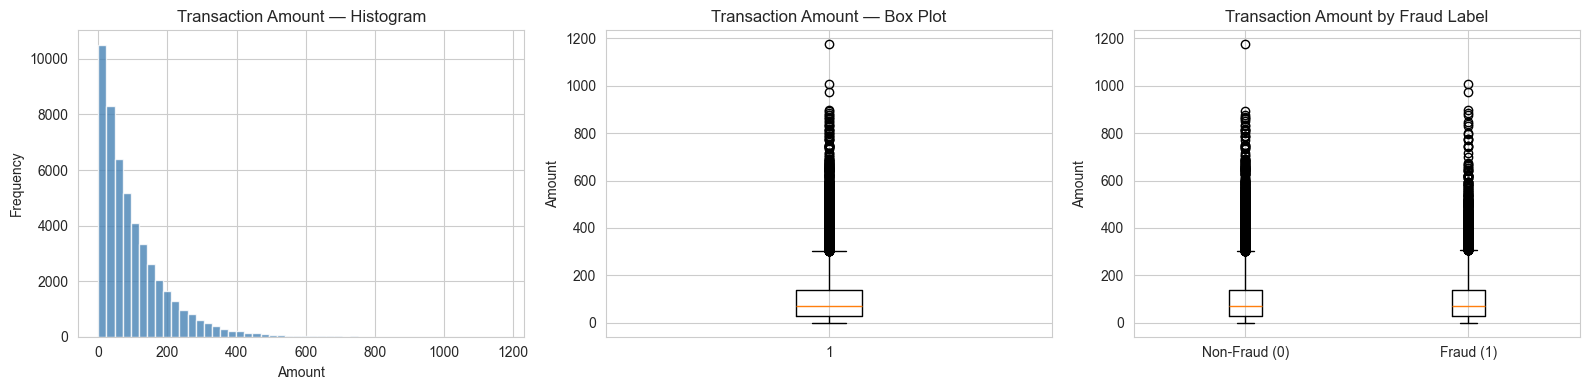


Decision: Transaction amounts in this synthetic dataset range from
  0.00 to 1174.14.
  These values represent plausible financial transactions.
  No outliers are removed — the data is retained as-is for model training.


In [13]:
# Visualize Transaction_Amount distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df["Transaction_Amount"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Transaction Amount — Histogram")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Frequency")

# Box plot
axes[1].boxplot(df["Transaction_Amount"], vert=True)
axes[1].set_title("Transaction Amount — Box Plot")
axes[1].set_ylabel("Amount")

# Box plot by Fraud_Label
fraud_0 = df.loc[df["Fraud_Label"] == 0, "Transaction_Amount"]
fraud_1 = df.loc[df["Fraud_Label"] == 1, "Transaction_Amount"]
axes[2].boxplot([fraud_0, fraud_1], tick_labels=["Non-Fraud (0)", "Fraud (1)"])
axes[2].set_title("Transaction Amount by Fraud Label")
axes[2].set_ylabel("Amount")

plt.tight_layout()
plt.show()

print("\nDecision: Transaction amounts in this synthetic dataset range from")
print(f"  {df['Transaction_Amount'].min():.2f} to {df['Transaction_Amount'].max():.2f}.")
print("  These values represent plausible financial transactions.")
print("  No outliers are removed — the data is retained as-is for model training.")

---
## 13. Feature Engineering — Date Components

Extract meaningful date-based features from the `Date` column.  
These are straightforward preprocessing-level features that capture temporal patterns  
without using the target variable or introducing leakage.

In [14]:
# Extract date components
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.dayofweek  # Monday=0, Sunday=6

print("Date-based features created:")
print(f"  Year:        unique values = {sorted(df['Year'].unique())}")
print(f"  Month:       range = [{df['Month'].min()}, {df['Month'].max()}]")
print(f"  Day:         range = [{df['Day'].min()}, {df['Day'].max()}]")
print(f"  Day_of_Week: range = [{df['Day_of_Week'].min()}, {df['Day_of_Week'].max()}] (Mon=0, Sun=6)")

print("\nSample of date features:")
print(df[["Date", "Year", "Month", "Day", "Day_of_Week"]].head(5).to_string(index=False))

Date-based features created:
  Year:        unique values = [np.int32(2023)]
  Month:       range = [1, 12]
  Day:         range = [1, 31]
  Day_of_Week: range = [0, 6] (Mon=0, Sun=6)

Sample of date features:
      Date  Year  Month  Day  Day_of_Week
2023-08-14  2023      8   14            0
2023-06-07  2023      6    7            2
2023-06-20  2023      6   20            1
2023-12-07  2023     12    7            3
2023-11-11  2023     11   11            5


---
## 14. Feature / Target Separation

Separate the dataset into:
- **`y`** — the target variable (`Fraud_Label`)
- **`X`** — all model input features (excluding identifiers, target, and the raw Date column)

Identifier columns (`Transaction_ID`, `User_ID`) and the original `Date` column are excluded from `X`  
because they are not meaningful model features. The extracted date components (`Year`, `Month`, `Day`, `Day_of_Week`) are included.

In [15]:
# Columns to exclude from model features
exclude_from_X = ["Transaction_ID", "User_ID", "Date", "Fraud_Label"]

# Target
y = df["Fraud_Label"].copy()

# Features (everything except identifiers, raw Date, and target)
X = df.drop(columns=exclude_from_X).copy()

print(f"Target (y): shape = {y.shape}, dtype = {y.dtype}")
print(f"Features (X): shape = {X.shape}")
print(f"\nFeature columns ({X.shape[1]}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col:35s} ({X[col].dtype})")

# Verify: Fraud_Label is NOT in X
assert "Fraud_Label" not in X.columns, "ERROR: Fraud_Label found in X — target leakage!"
assert "Transaction_ID" not in X.columns, "ERROR: Transaction_ID found in X!"
assert "User_ID" not in X.columns, "ERROR: User_ID found in X!"
print("\n✓ Confirmed: Fraud_Label is NOT in X (no target leakage).")
print("✓ Confirmed: Transaction_ID and User_ID are NOT in X.")

Target (y): shape = (50000,), dtype = int64
Features (X): shape = (50000, 14)

Feature columns (14):
   1. Transaction_Amount                  (float64)
   2. Transaction_Type                    (object)
   3. Account_Balance                     (float64)
   4. Device_Type                         (object)
   5. Location                            (object)
   6. Merchant_Category                   (object)
   7. Previous_Fraudulent_Activity        (int64)
   8. Daily_Transaction_Count             (int64)
   9. Card_Type                           (object)
  10. Card_Age                            (int64)
  11. Year                                (int32)
  12. Month                               (int32)
  13. Day                                 (int32)
  14. Day_of_Week                         (int32)

✓ Confirmed: Fraud_Label is NOT in X (no target leakage).
✓ Confirmed: Transaction_ID and User_ID are NOT in X.


---
## 15. Preprocessing Pipeline Design — Encoding & Scaling

Design a reproducible scikit-learn preprocessing pipeline using `ColumnTransformer`.

**Strategy:**
- **Categorical features** → `OneHotEncoder` with `handle_unknown='ignore'` (safe for unseen categories at inference time)
- **Numerical features** → `StandardScaler` (zero mean, unit variance)

**Important:** The pipeline is defined here but **not fitted** on the full dataset.  
In Step 7 (model development), it should be fitted **only on training data** to avoid data leakage.

In [16]:
# Identify feature types from X
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}):   {numerical_features}")
print(f"\nTotal features: {len(categorical_features) + len(numerical_features)}")

Categorical features (5): ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type']
Numerical features (5):   ['Transaction_Amount', 'Account_Balance', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Age']

Total features: 10


In [17]:
# Define the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "num",
            StandardScaler(),
            numerical_features,
        ),
    ],
    remainder="drop",  # Drop any columns not explicitly listed
)

print("Preprocessing ColumnTransformer defined:")
print(f"  Categorical → OneHotEncoder (drop='first', handle_unknown='ignore')")
print(f"    Columns: {categorical_features}")
print(f"  Numerical  → StandardScaler")
print(f"    Columns: {numerical_features}")
print()
print("⚠ NOTE: This preprocessor is NOT yet fitted.")
print("  In Step 7, fit it ONLY on training data to prevent data leakage.")
print("  Example usage in Step 7:")
print("    X_train_processed = preprocessor.fit_transform(X_train)")
print("    X_test_processed  = preprocessor.transform(X_test)")

Preprocessing ColumnTransformer defined:
  Categorical → OneHotEncoder (drop='first', handle_unknown='ignore')
    Columns: ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type']
  Numerical  → StandardScaler
    Columns: ['Transaction_Amount', 'Account_Balance', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Age']

⚠ NOTE: This preprocessor is NOT yet fitted.
  In Step 7, fit it ONLY on training data to prevent data leakage.
  Example usage in Step 7:
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed  = preprocessor.transform(X_test)


In [18]:
# Quick validation: verify the pipeline runs on a small sample without errors
sample_X = X.head(5)
sample_transformed = preprocessor.fit_transform(sample_X)

# Get output feature names
output_feature_names = preprocessor.get_feature_names_out()

print(f"Pipeline validation (on 5-row sample):")
print(f"  Input shape:  {sample_X.shape}")
print(f"  Output shape: {sample_transformed.shape}")
print(f"  Output features ({len(output_feature_names)}):")
for i, name in enumerate(output_feature_names, 1):
    print(f"    {i:2d}. {name}")

print("\n✓ Pipeline executes successfully.")
print("  Ready for use in Step 7 (fit on training data only).")

Pipeline validation (on 5-row sample):
  Input shape:  (5, 14)
  Output shape: (5, 17)
  Output features (17):
     1. cat__Transaction_Type_Bank Transfer
     2. cat__Transaction_Type_Online
     3. cat__Transaction_Type_POS
     4. cat__Device_Type_Mobile
     5. cat__Device_Type_Tablet
     6. cat__Location_New York
     7. cat__Location_Sydney
     8. cat__Merchant_Category_Electronics
     9. cat__Merchant_Category_Restaurants
    10. cat__Merchant_Category_Travel
    11. cat__Card_Type_Mastercard
    12. cat__Card_Type_Visa
    13. num__Transaction_Amount
    14. num__Account_Balance
    15. num__Previous_Fraudulent_Activity
    16. num__Daily_Transaction_Count
    17. num__Card_Age

✓ Pipeline executes successfully.
  Ready for use in Step 7 (fit on training data only).


---
## 16. Final Preprocessing Validation

Verify the preprocessed dataset's integrity: shape, types, missing values, duplicates, target distribution, and data quality.

In [19]:
print("=" * 60)
print("FINAL PREPROCESSING VALIDATION")
print("=" * 60)

# 1. Full DataFrame shape (df still has all columns including IDs)
print(f"\n1. Full DataFrame shape: {df.shape}")
print(f"   Feature matrix X shape: {X.shape}")
print(f"   Target vector y shape:  {y.shape}")

# 2. Data types of X
print(f"\n2. Data types in X:")
for col in X.columns:
    print(f"   {col:35s} {str(X[col].dtype)}")

# 3. Missing values
missing_X = X.isnull().sum().sum()
missing_y = y.isnull().sum()
print(f"\n3. Missing values in X: {missing_X}")
print(f"   Missing values in y: {missing_y}")
if missing_X == 0 and missing_y == 0:
    print("   ✓ No missing values.")

# 4. Duplicates in X
dup_X = X.duplicated().sum()
print(f"\n4. Duplicate rows in X: {dup_X}")

# 5. Target distribution
print(f"\n5. Target distribution (y = Fraud_Label):")
for val, count in y.value_counts().sort_index().items():
    label = "Non-Fraud" if val == 0 else "Fraud"
    print(f"   {val} ({label}): {count:,}  ({count / len(y) * 100:.2f}%)")

# 6. Infinite values in X numeric columns
X_numeric = X.select_dtypes(include=[np.number])
inf_in_X = np.isinf(X_numeric).sum().sum()
print(f"\n6. Infinite values in X (numeric): {inf_in_X}")
if inf_in_X == 0:
    print("   ✓ No infinite values.")

# 7. Target leakage check
print(f"\n7. Target leakage check:")
print(f"   'Fraud_Label' in X.columns → {('Fraud_Label' in X.columns)}")
print(f"   'Transaction_ID' in X.columns → {('Transaction_ID' in X.columns)}")
print(f"   'User_ID' in X.columns → {('User_ID' in X.columns)}")
if "Fraud_Label" not in X.columns:
    print("   ✓ No target leakage detected.")

# 8. Preprocessor status
print(f"\n8. Preprocessor pipeline: defined and validated.")
print(f"   Categorical features → OneHotEncoder: {categorical_features}")
print(f"   Numerical features → StandardScaler:  {numerical_features}")

print("\n" + "=" * 60)
print("✓ ALL VALIDATIONS PASSED")
print("=" * 60)

FINAL PREPROCESSING VALIDATION

1. Full DataFrame shape: (50000, 18)
   Feature matrix X shape: (50000, 14)
   Target vector y shape:  (50000,)

2. Data types in X:
   Transaction_Amount                  float64
   Transaction_Type                    object
   Account_Balance                     float64
   Device_Type                         object
   Location                            object
   Merchant_Category                   object
   Previous_Fraudulent_Activity        int64
   Daily_Transaction_Count             int64
   Card_Type                           object
   Card_Age                            int64
   Year                                int32
   Month                               int32
   Day                                 int32
   Day_of_Week                         int32

3. Missing values in X: 0
   Missing values in y: 0
   ✓ No missing values.

4. Duplicate rows in X: 0

5. Target distribution (y = Fraud_Label):
   0 (Non-Fraud): 33,933  (67.87%)
   1 (Fraud): 

---
## 17. Final Dataset Summary

In [20]:
print("=" * 60)
print("STEP 6 — DATA CLEANING & PREPROCESSING SUMMARY")
print("=" * 60)

print("""
1. CLEANING:
   • Missing values:  0 found → no imputation needed.
   • Duplicate rows:  0 found → no rows removed.
   • Whitespace in categorical columns: checked and clean.
   • No rows were removed from the dataset.

2. TYPE CONVERSION:
   • Date column: converted from string ('14 August 2023' format)
     to pandas datetime64. All values parsed successfully.

3. NUMERIC VALIDATION:
   • Transaction_Amount:  no negatives, no NaN, no inf.
   • Account_Balance:     no negatives, no NaN, no inf.
   • Previous_Fraudulent_Activity: valid binary (0, 1).
   • Daily_Transaction_Count: valid positive integers.
   • Card_Age: valid positive integers.

4. CATEGORICAL VALIDATION:
   • Transaction_Type: 4 clean categories.
   • Device_Type:      3 clean categories.
   • Location:         5 clean categories.
   • Merchant_Category: 5 clean categories.
   • Card_Type:        4 clean categories.

5. TARGET (Fraud_Label):
   • Binary (0, 1). Not transformed.
   • Not included in feature matrix X.

6. IDENTIFIERS:
   • Transaction_ID and User_ID: kept in df for identification.
   • Not encoded, scaled, or included in X.

7. FEATURE ENGINEERING:
   • Extracted: Year, Month, Day, Day_of_Week from Date.

8. OUTLIER INVESTIGATION:
   • Transaction_Amount outliers were investigated.
   • No rows were removed — values are plausible for this dataset.

9. PREPROCESSING PIPELINE:
   • ColumnTransformer defined with:
     - OneHotEncoder for categorical features (drop='first',
       handle_unknown='ignore')
     - StandardScaler for numerical features
   • Pipeline validated on a sample but NOT fitted on full data.
   • Must be fitted on training data only in Step 7.

10. DATA PROTECTION:
    • Raw CSV was NOT modified.
    • All work performed on a working copy (df).

LIMITATIONS / OBSERVATIONS:
   • The dataset is synthetic and well-formed (no real-world
     messiness like encoding issues, multi-language entries, etc.).
   • Class imbalance (~32% fraud) exists but is not addressed here
     — SMOTE or other resampling belongs to model training (Step 7).
""")

print(f"Dataset shape (original):     {raw_df.shape}")
print(f"Dataset shape (after prep):   {df.shape}")
print(f"Feature matrix X shape:       {X.shape}")
print(f"Target vector y shape:        {y.shape}")

STEP 6 — DATA CLEANING & PREPROCESSING SUMMARY

1. CLEANING:
   • Missing values:  0 found → no imputation needed.
   • Duplicate rows:  0 found → no rows removed.
   • Whitespace in categorical columns: checked and clean.
   • No rows were removed from the dataset.

2. TYPE CONVERSION:
   • Date column: converted from string ('14 August 2023' format)
     to pandas datetime64. All values parsed successfully.

3. NUMERIC VALIDATION:
   • Transaction_Amount:  no negatives, no NaN, no inf.
   • Account_Balance:     no negatives, no NaN, no inf.
   • Previous_Fraudulent_Activity: valid binary (0, 1).
   • Daily_Transaction_Count: valid positive integers.
   • Card_Age: valid positive integers.

4. CATEGORICAL VALIDATION:
   • Transaction_Type: 4 clean categories.
   • Device_Type:      3 clean categories.
   • Location:         5 clean categories.
   • Merchant_Category: 5 clean categories.
   • Card_Type:        4 clean categories.

5. TARGET (Fraud_Label):
   • Binary (0, 1). Not transf

---
## 18. Explicit Boundary — End of Step 6

---

**Step 6 — Data Cleaning & Preprocessing completed.**

The next step (Step 7) will cover **Model Development & Training**, which includes:
- Train-test splitting
- Fitting the preprocessing pipeline on training data
- Handling class imbalance (if needed)
- Training and evaluating classification models

**Step 7 is NOT implemented in this notebook.**